# 3-year pumping tests

Domain-aware outlet from `domains/<DOMAIN>/config.ini`.

Plots last 3 spinup years + 3 pumping years. Set `DOMAIN` below to `wolf2` or `potomac2`.

In [1]:
try:
    from drought_ensemble.analysis.paper_figures import utils
except ImportError:
    import sys
    from pathlib import Path

    def _find_project_root() -> Path:
        for candidate in [Path.cwd(), *Path.cwd().resolve().parents]:
            if (candidate / "classes" / "Domain.py").is_file():
                return candidate
            nested = candidate / "drought-ensemble"
            if (nested / "classes" / "Domain.py").is_file():
                return nested
        raise ImportError(
            "Install with `pip install -e .` from drought-ensemble/, "
            "or run this notebook from inside the project tree."
        )

    _root = _find_project_root()
    if str(_root) not in sys.path:
        sys.path.insert(0, str(_root))

    from analysis.paper_figures import utils


In [2]:
import configparser
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

DOMAIN = "wolf2"  # potomac2 | wolf2
ENSEMBLE = "3_year_pumping_tests"
MEMBERS = ["pumping_1e-7", "pumping_1e-6", "pumping_1e-5", "pumping_1e-4"]

SPINUP_YEARS = 40
SPINUP_YEARS_TO_KEEP = 3
PLOT_START_YEAR = SPINUP_YEARS - SPINUP_YEARS_TO_KEEP  # 37
PUMPING_START_YEAR = SPINUP_YEARS  # 40
INTERVAL = 219

PROJECT_ROOT = Path("/glade/derecho/scratch/bwest/drought-ensemble")
_cfg = configparser.ConfigParser()
_cfg_path = PROJECT_ROOT / "domains" / DOMAIN / "config.ini"
if not _cfg.read(_cfg_path):
    raise FileNotFoundError(_cfg_path)
OUTLET_X = int(_cfg.get("DEFAULT", "OUTLET_X"))
OUTLET_Y = int(_cfg.get("DEFAULT", "OUTLET_Y"))
print(DOMAIN, "outlet", (OUTLET_X, OUTLET_Y))


wolf2 outlet (18, 21)


In [3]:
runs = {
    member: utils.read_simulation_data(
        ENSEMBLE, member, DOMAIN, start_year=PLOT_START_YEAR
    )
    for member in MEMBERS
}
for member, ds in runs.items():
    print(
        f"{member}: time {float(ds.time.min()):.2f} -> {float(ds.time.max()):.2f} yr"
    )

_ds0 = next(iter(runs.values()))
assert 0 <= OUTLET_X < _ds0.sizes["x"] and 0 <= OUTLET_Y < _ds0.sizes["y"], (
    f"Outlet ({OUTLET_X}, {OUTLET_Y}) out of bounds for {DOMAIN} "
    f"grid x={_ds0.sizes['x']}, y={_ds0.sizes['y']}"
)
print(f"outlet ok for grid x={_ds0.sizes['x']}, y={_ds0.sizes['y']}")


pumping_1e-7: time 37.00 -> 43.00 yr
pumping_1e-6: time 37.00 -> 43.00 yr
pumping_1e-5: time 37.00 -> 43.00 yr
pumping_1e-4: time 37.00 -> 43.00 yr
outlet ok for grid x=78, y=41


plotting with outlet (18, 21)


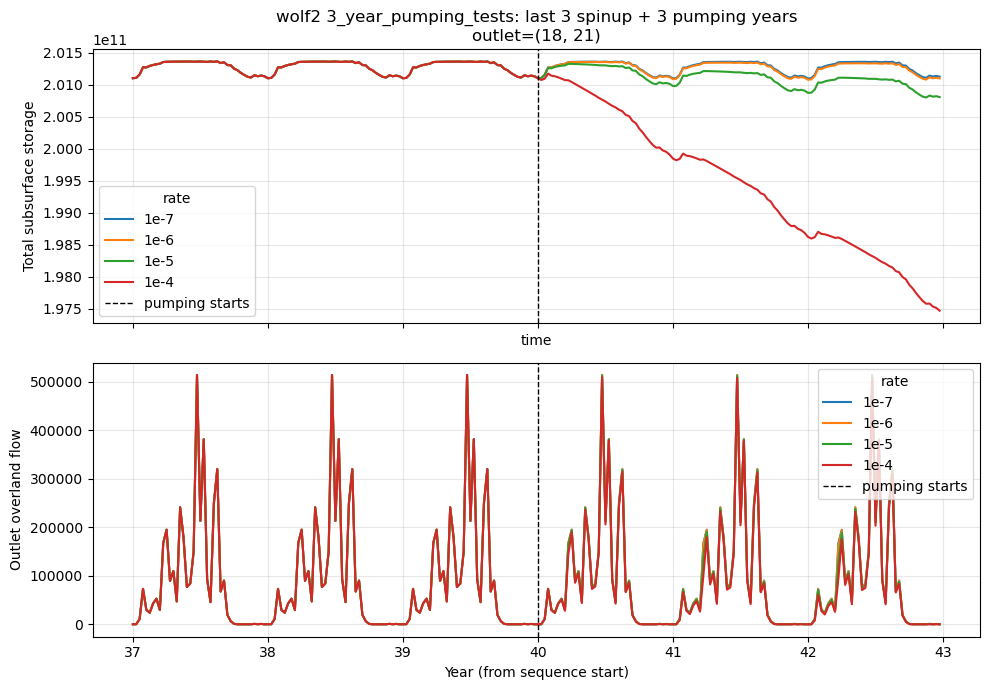

In [4]:
# Re-read outlet in this cell so a stale kernel cannot keep potomac (66, 135)
_cfg = configparser.ConfigParser()
_cfg.read(PROJECT_ROOT / "domains" / DOMAIN / "config.ini")
OUTLET_X = int(_cfg.get("DEFAULT", "OUTLET_X"))
OUTLET_Y = int(_cfg.get("DEFAULT", "OUTLET_Y"))
print("plotting with outlet", (OUTLET_X, OUTLET_Y))


def total_storage(ds):
    return ds.storage.isel(time=slice(0, None, INTERVAL)).sum(dim=["x", "y", "z"])


def outlet_flow(ds):
    return ds.overland_flow.isel(
        x=OUTLET_X, y=OUTLET_Y, time=slice(0, None, INTERVAL)
    )


fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

for member, ds in runs.items():
    label = member.replace("pumping_", "")
    total_storage(ds).plot(ax=axes[0], label=label)
    outlet_flow(ds).plot(ax=axes[1], label=label)

for ax in axes:
    ax.axvline(PUMPING_START_YEAR, color="k", ls="--", lw=1, label="pumping starts")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Total subsurface storage")
axes[0].set_title(
    f"{DOMAIN} {ENSEMBLE}: last {SPINUP_YEARS_TO_KEEP} spinup + 3 pumping years\n"
    f"outlet=({OUTLET_X}, {OUTLET_Y})"
)
axes[0].legend(title="rate")

axes[1].set_ylabel("Outlet overland flow")
axes[1].set_xlabel("Year (from sequence start)")
handles, labels = axes[1].get_legend_handles_labels()
uniq = dict(zip(labels, handles))
axes[1].legend(uniq.values(), uniq.keys(), title="rate")

plt.tight_layout()
plt.show()


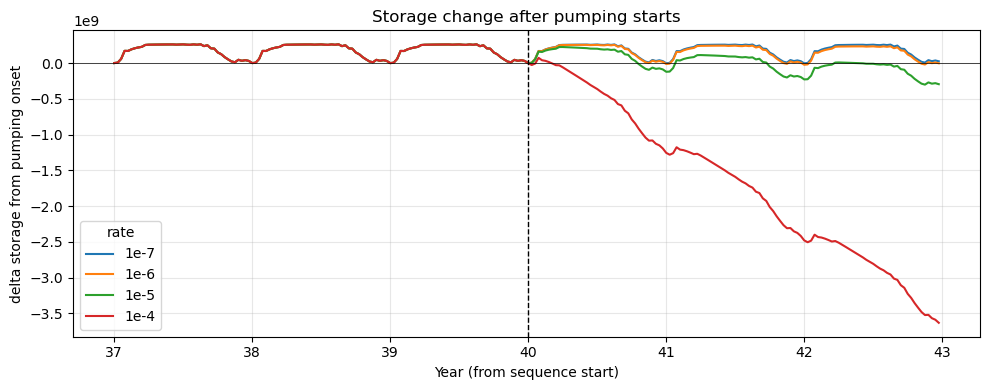

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))

for member, ds in runs.items():
    stor = total_storage(ds)
    t = stor.time.values
    i0 = int(np.argmin(np.abs(t - PUMPING_START_YEAR)))
    anomaly = stor - float(stor.isel(time=i0).values)
    anomaly.plot(ax=ax, label=member.replace("pumping_", ""))

ax.axvline(PUMPING_START_YEAR, color="k", ls="--", lw=1)
ax.axhline(0, color="k", lw=0.5)
ax.set_ylabel("delta storage from pumping onset")
ax.set_xlabel("Year (from sequence start)")
ax.set_title("Storage change after pumping starts")
ax.legend(title="rate")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
